## Diffusion model 10: ECG Dataset

Author: diego.camarero@estudiante.uam.es

In [ ]:
!pip install -q wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 67.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.


In [ ]:
experiment_number = '10'

kernel_sizes = (9, 9, 9, 9)

lambda_min = 0.5
lambda_max = 5.0

dataset_size = 9246
n_points = 500

training_epochs = 500

experiment_name = f"training_diffusion_{experiment_number}_ECG"

In [ ]:
from google.colab import drive
import os
import sys
import torch

drive.mount('/content/drive')
PROJECT_PATH = '/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Scalar diffusion/notebooks'
%cd "{PROJECT_PATH}"


BASE_DIR = os.path.abspath("..")
CHECKPOINTS_DIR = os.path.join(BASE_DIR, "checkpoints")

if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n[INFO] Running on device: {device}\n")

Mounted at /content/drive
/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Scalar diffusion/notebooks

[INFO] Running on device: cuda



In [ ]:
from utils.reproducibility import seed_everything, seed_worker

seed = 42
seed_everything(seed)

In [ ]:
# Jupyter
# %load_ext autoreload
# %autoreload 2

# Standard library
from functools import partial

# Third-party
import numpy as np
import pandas as pd

# PyTorch
import torch
from torch.utils.data import DataLoader
from torch.optim import Adam

# Project modules
import diffusion.diffusion_process as dfp

from models.score_model import UNetScoreModel

from data.ecg_dataset import (
    load_ecg_data,
)

from utils.metrics import (
    compute_dataset_metrics,
    full_report,
    checkpoint_summary,
    plot_training_evolution,
    plot_loss_history,
)


from utils.checkpoints import (
    save_checkpoint,
    load_checkpoint,
)

from utils.training_plots import (
    plot_function_grid,
    plot_ou_diffusion_process,
    plot_distribution_convergence,
)

## Dataset creation

In [ ]:
from data.ecg_dataset import apply_bandpass_filter

LEAD = 1
SAMPLING_RATE = 100 # or 500
MAX_SAMPLES = 9246
DATASET_PATH = '/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/ECG dataset/'

CACHE_PATH = DATASET_PATH + f'cache_lead{LEAD}_sr{SAMPLING_RATE}_n{MAX_SAMPLES}.pt'

print("Loading from cache...")
checkpoint = torch.load(CACHE_PATH)
data_train = checkpoint['data'][:dataset_size, :, :n_points]
data_train = apply_bandpass_filter(data_train, SAMPLING_RATE)
print(f"Dataset shape: {data_train.shape}")

# For later metrics comparison
real_metrics_df = compute_dataset_metrics(data_train, fs=SAMPLING_RATE)
real_ok_df = real_metrics_df[real_metrics_df['success']]

# Normalize dataset
data_mean = data_train.mean()
data_std = data_train.std()
data_eps = 1e-8
data_train_norm = (data_train - data_mean) / (data_std + data_eps)

Loading from cache...
Dataset shape: torch.Size([9246, 1, 500])


torch.Size([8, 1, 500])


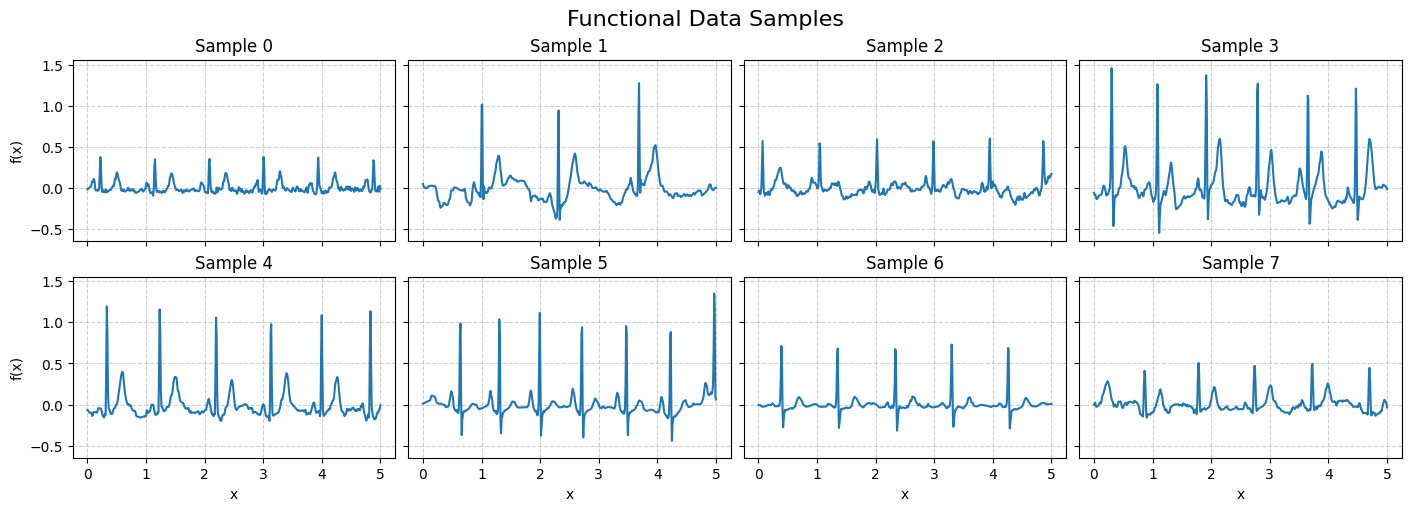

In [ ]:
# Create functional dataset

N, _, M = data_train.shape
x_inf, x_sup = 0.0, 5.0
axis_x = torch.linspace(x_inf, x_sup, M)

# Plot some examples of the dataset

n_examples = 8
examples = torch.stack([data_train[i] for i in range(n_examples)])
print(examples.shape)

plot_function_grid(
    examples,
    n_plots=n_examples,
    axis_x=axis_x,
)

## Diffusion process

In [ ]:
t_0 = 0.0
T = 1.0
t_eps = 1.0e-3

lambda_t = lambda t: lambda_min + (t-t_0) / (T-t_0) * (lambda_max - lambda_min)

def drift_coefficient(x_t, t):
    t = t.view(-1, 1, 1)
    return - lambda_t(t) * x_t

def diffusion_coefficient(t):
    t = t.view(-1, 1, 1)
    return torch.sqrt(2 * lambda_t(t))

def mu_t(x_0, t):
    return x_0 * torch.exp(-lambda_min*(t-t_0) - (t-t_0)**2 / (2*(T-t_0)) * (lambda_max - lambda_min))

def sigma_t(t):
    return torch.sqrt(1 - torch.exp(-2 * lambda_min * (t-t_0) - (t-t_0)**2 /(T-t_0) * (lambda_max - lambda_min)))

def inverse_mu_t(t):
    return torch.exp(lambda_min*(t-t_0) + (t-t_0)**2 / (2*(T-t_0)) * (lambda_max - lambda_min))

diffusion_process = dfp.GaussianDiffusionProcess(
    drift_coefficient,
    diffusion_coefficient,
    mu_t,
    sigma_t,
    t_0=t_0,
    t_end=T,
    t_eps=t_eps,
)

torch.Size([9246, 100, 1, 500])


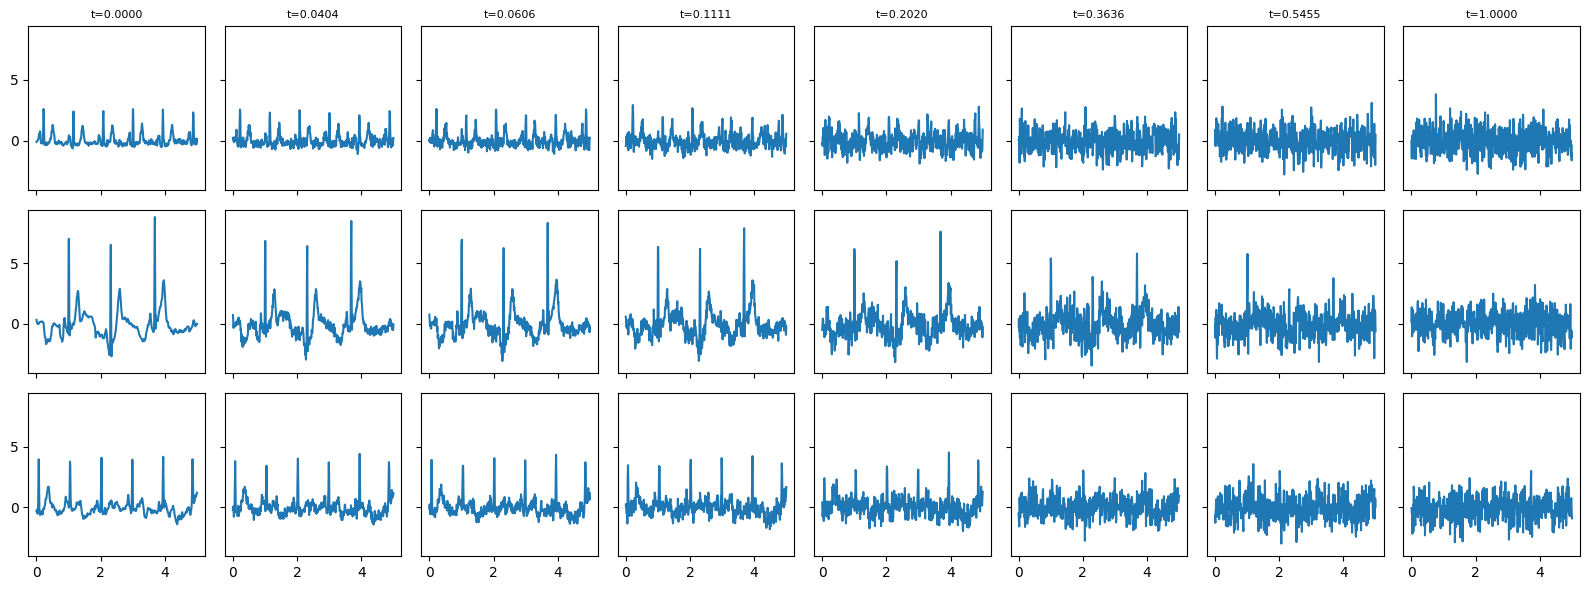

In [ ]:
torch.manual_seed(seed)
n_steps = 100
times, X = dfp.euler_maruyama_integrator(
    x_initial=data_train_norm[:].to(device),
    t_start=t_0,
    t_end=T,
    n_times=n_steps,
    drift_coefficient=drift_coefficient,
    diffusion_coefficient=diffusion_coefficient,
)
print(X.shape)

plot_ou_diffusion_process(
    X,
    axis_x,
    num_steps=8,
    t_start=t_0,
    t_end=T,
)

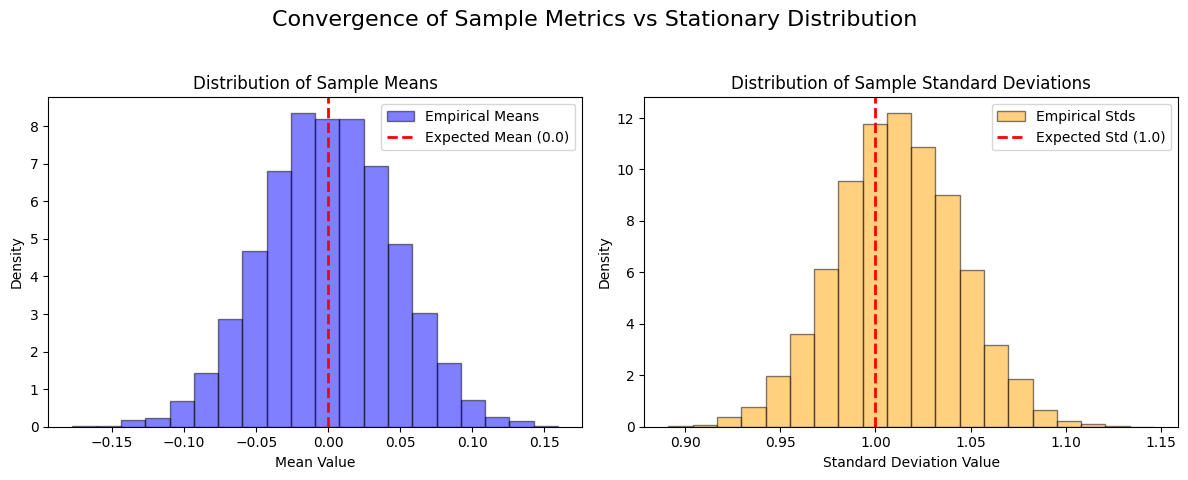

In [ ]:
plot_distribution_convergence(
    X,
    loc_stationary=0.0,
    scale_stationary=1.0,
)

## Training

In [ ]:
# Define the score model

def multiply_inv_sigma(h,t):
    h = h / sigma_t(t)[:, None]
    return h

score_model = UNetScoreModel(
    multiply_inv_sigma=multiply_inv_sigma,
    kernel_sizes=kernel_sizes,
    random_state=seed,
    device=device,
)

learning_rate = 1.0e-3
optimizer = Adam(score_model.parameters(), lr=learning_rate)
n_epochs = training_epochs
save_every = max(1, n_epochs // 10)

  0%|          | 0/500 [00:00<?, ?it/s]

Checkpoint saved at: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Scalar diffusion/checkpoints/training_diffusion_10_ECG/checkpoint_epoch_1.pth
Epoch: 1. Loss: 188.410633. Time: 00:05
Checkpoint saved at: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Scalar diffusion/checkpoints/training_diffusion_10_ECG/checkpoint_epoch_50.pth
Epoch: 50. Loss: 33.027963. Time: 03:26
Checkpoint saved at: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Scalar diffusion/checkpoints/training_diffusion_10_ECG/checkpoint_epoch_100.pth
Epoch: 100. Loss: 31.029272. Time: 06:51
Checkpoint saved at: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Scalar diffusion/checkpoints/training_diffusion_10_ECG/checkpoint_epoch_150.pth
Epoch: 150. Loss: 29.999664. Time: 10:16
Checkpoint saved at: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Scalar diffusion/checkpoints/training_diffusion_10_ECG/checkpoint_epoch_200.pth
Epoch: 200. Loss: 29.

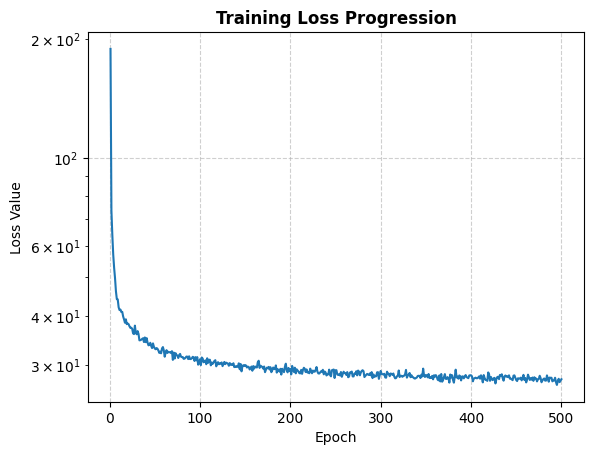

In [ ]:
# Train model
import time
import torchvision.transforms as transforms
import tqdm
from tqdm.notebook import tqdm, trange

batch_size = 32

data_loader = DataLoader(
    data_train_norm,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    worker_init_fn=seed_worker,
)

tqdm_epoch = trange(n_epochs)

loss_history = {
    "epoch": [],
    "loss": []
}

start_time = time.time()
for epoch in tqdm_epoch:
    avg_loss = 0.0
    num_items = 0
    for x in data_loader:
        x = x.to(device)
        loss = diffusion_process.loss_function(score_model, x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        avg_loss += loss.item() * x.shape[0]
        num_items += x.shape[0]

    epoch_loss = avg_loss / num_items
    elapsed_time = time.time() - start_time
    tqdm_epoch.set_description('Average Loss: {:5f}'.format(epoch_loss))

    loss_history["epoch"].append(epoch + 1)
    loss_history["loss"].append(epoch_loss)

    if epoch == 0 or (epoch + 1) % save_every == 0:
        save_checkpoint(
            epoch=epoch,
            model=score_model,
            optimizer=optimizer,
            loss=epoch_loss,
            elapsed_time=elapsed_time,
            experiment_name=experiment_name,
            checkpoints_dir=CHECKPOINTS_DIR,
        )

if n_epochs % save_every != 0:
    save_checkpoint(
        epoch=n_epochs - 1,
        model=score_model,
        optimizer=optimizer,
        loss=epoch_loss,
        elapsed_time=elapsed_time,
        experiment_name=experiment_name,
        checkpoints_dir=CHECKPOINTS_DIR,
    )

plot_loss_history(loss_history)

## Synthetic data generation

In [ ]:
# Compute results

results = []

saved_epochs = list(range(save_every, n_epochs + 1, save_every))
saved_epochs = [1] + saved_epochs

checkpoint_paths = [
    os.path.join(
        CHECKPOINTS_DIR,
        experiment_name,
        f"checkpoint_epoch_{epoch}.pth"
    )
    for epoch in saved_epochs
]

def backward_drift_coefficient(x_t, t, drift_coefficient, diffusion_coefficient, score_model):
    score = score_model(x_t, t)
    return drift_coefficient(x_t, t) - diffusion_coefficient(t).view(-1, 1, 1) ** 2 * score

n_functions = 9246
torch.manual_seed(seed)
noise_T = torch.randn(n_functions, 1, M, device=device)

for ckpt_path in checkpoint_paths:

    score_model, optimizer, epoch, loss, elapsed_time = load_checkpoint(ckpt_path, score_model, optimizer)
    score_model.eval()

    torch.manual_seed(seed)

    with torch.no_grad():
        times, synthetic_functions_t = dfp.euler_maruyama_integrator(
                x_initial=noise_T,
                t_start=T,
                t_end=t_0 + t_eps,
                n_times=n_steps,
                drift_coefficient=partial(
                    backward_drift_coefficient,
                    drift_coefficient=drift_coefficient,
                    diffusion_coefficient=diffusion_coefficient,
                    score_model=score_model,
                ),
                diffusion_coefficient=diffusion_coefficient,
            )

        synthetic_functions_norm = dfp.inverse_Tweedie_formula(
            x_t=synthetic_functions_t[:, -1, :, :],
            t=t_eps,
            inv_mu_t=inverse_mu_t,
            sigma_t=sigma_t,
            score_model=score_model,
        )

    synthetic_functions = (synthetic_functions_norm * (data_std + data_eps) + data_mean)

    gen_metrics_df = compute_dataset_metrics(synthetic_functions, fs=SAMPLING_RATE)

    summary = checkpoint_summary(real_ok_df, gen_metrics_df)
    summary = {"epoch": epoch, **summary}

    results.append(summary)

Checkpoint loaded from: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Scalar diffusion/checkpoints/training_diffusion_10_ECG/checkpoint_epoch_1.pth
Epoch: 1. Loss: 188.410633. Time: 00:05
Checkpoint loaded from: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Scalar diffusion/checkpoints/training_diffusion_10_ECG/checkpoint_epoch_50.pth
Epoch: 50. Loss: 33.027963. Time: 03:26
Checkpoint loaded from: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Scalar diffusion/checkpoints/training_diffusion_10_ECG/checkpoint_epoch_100.pth
Epoch: 100. Loss: 31.029272. Time: 06:51
Checkpoint loaded from: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Scalar diffusion/checkpoints/training_diffusion_10_ECG/checkpoint_epoch_150.pth
Epoch: 150. Loss: 29.999664. Time: 10:16
Checkpoint loaded from: /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/Scalar diffusion/checkpoints/training_diffusion_10_ECG/checkpoint_epoch_200.pth
Epoch:

## Results

In [ ]:
df = pd.DataFrame(results)
print(df)

    epoch  success_rate      wd_hr  wd_rr_mean  wd_rr_std
0       1      0.418343  17.291868    0.148349   0.235090
1      50      0.887411   4.906501    0.029528   0.055582
2     100      0.920614   8.076100    0.051508   0.054233
3     150      0.777309   7.666568    0.048303   0.050061
4     200      0.918992   4.466817    0.027130   0.054875
5     250      0.910231   6.883613    0.039061   0.047576
6     300      0.877136   5.814893    0.032698   0.053360
7     350      0.918776   7.649741    0.045961   0.049782
8     400      0.915531  11.102044    0.076612   0.047931
9     450      0.898875   2.316592    0.012102   0.054146
10    500      0.851720   5.492805    0.033270   0.047083


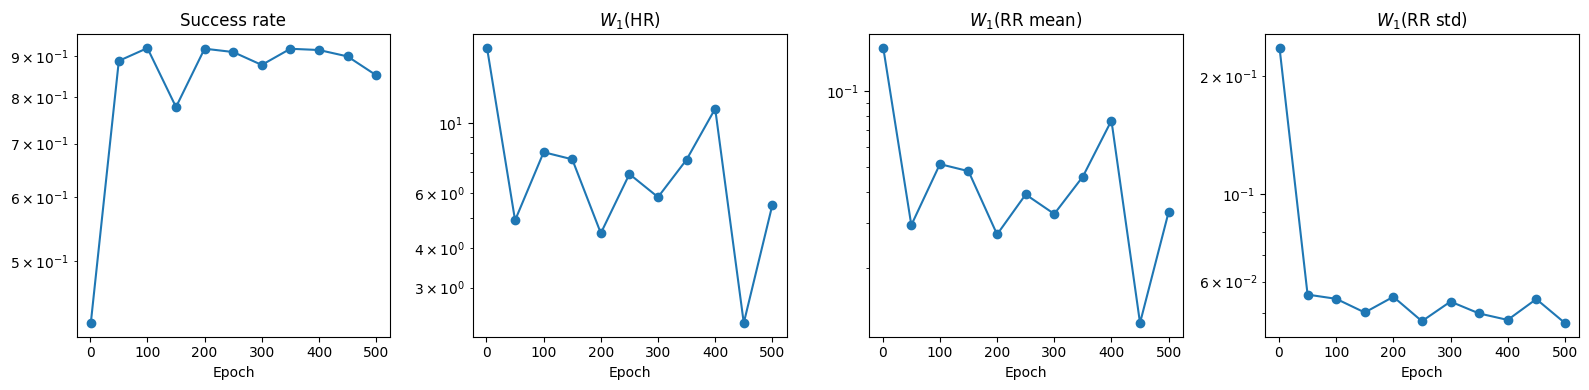

In [ ]:
metrics = ["success_rate", "wd_hr", "wd_rr_mean", "wd_rr_std"]
titles = ["Success rate", r"$W_1$(HR)", r"$W_1$(RR mean)", r"$W_1$(RR std)"]
plot_training_evolution(df, metrics, titles)

R-peak detection success rate — real: 93.1%, generated: 85.2%


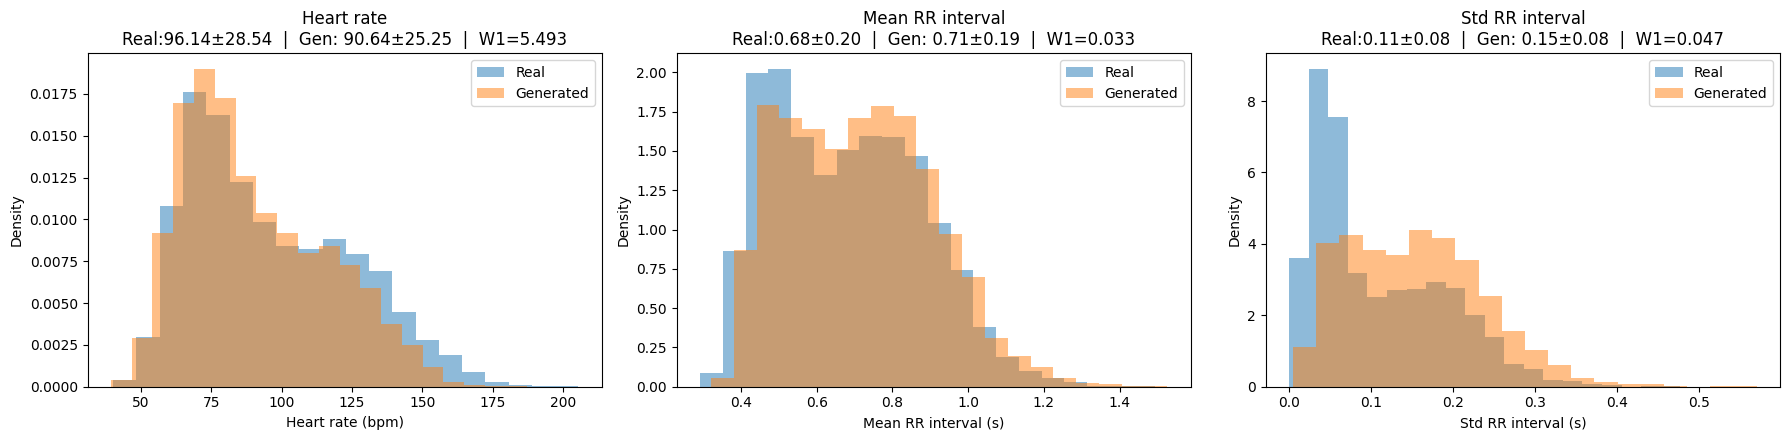

In [ ]:
real_metrics_df = compute_dataset_metrics(data_train, fs=SAMPLING_RATE)
gen_metrics_df = compute_dataset_metrics(synthetic_functions, fs=SAMPLING_RATE)
report = full_report(real_metrics_df, gen_metrics_df)

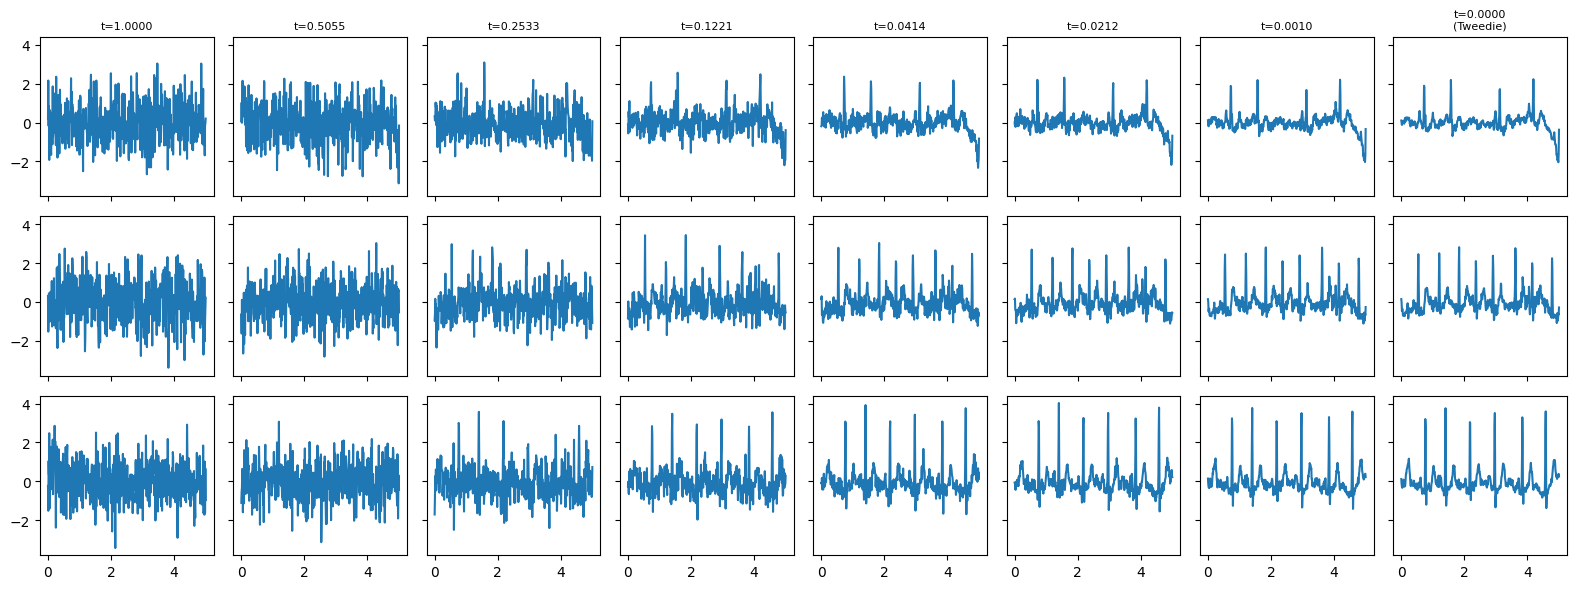

In [ ]:
synthetic_functions_t = torch.cat(
    [synthetic_functions_t, synthetic_functions_norm.unsqueeze(1)],
    dim=1,
    )

plot_ou_diffusion_process(
    synthetic_functions_t,
    axis_x,
    num_steps=8,
    t_start=T,
    t_end=t_eps,
    tweedie_final=True,
)

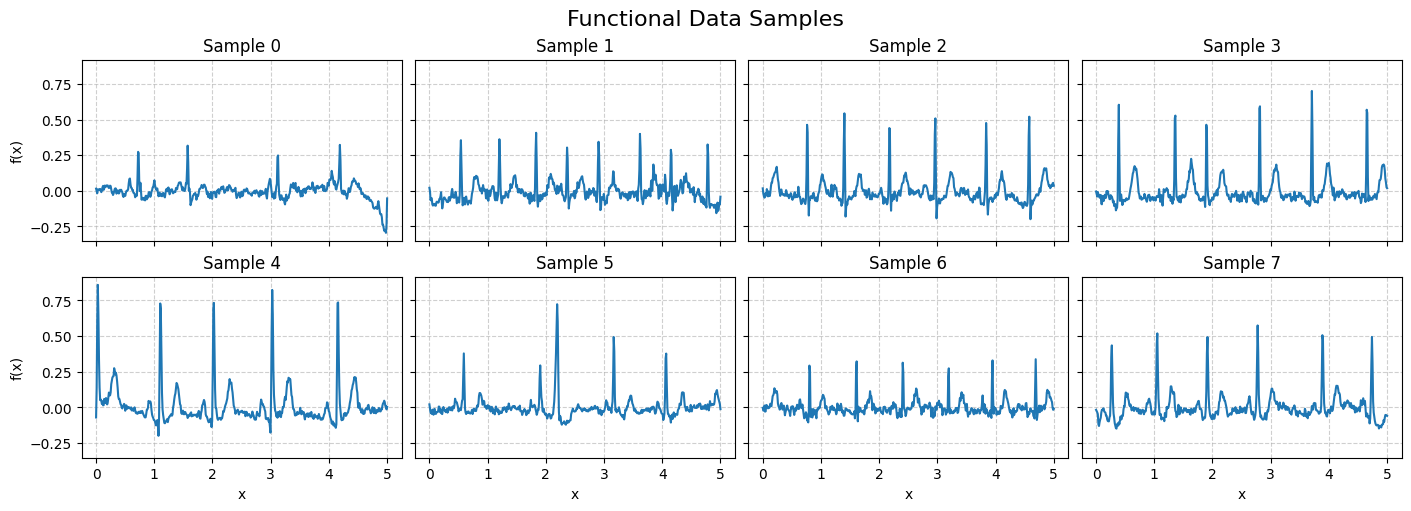

In [ ]:
plot_function_grid(
    synthetic_functions,
    n_plots=8,
    axis_x=axis_x,
)